In [14]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/finaltask/test.pickle
/kaggle/input/finaltask/generated_data.pickle
/kaggle/input/finaltask/train.pickle
/kaggle/input/finaltask/gan_model.pth


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_pickle('/kaggle/input/finaltask/test.pickle')

In [17]:
# Display first few rows
display(df.head())

# Basic info
print("\nShape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

,sensor_data,label,model,velocity,mass,deceleration_average
0,"[[-3.9346010604972648, -0.05542138047796165, -...",0,Variant Comfortline,30,1530.0,-3.393840
1,"[[-3.4810850496899266, 0.06682498013278597, -0...",0,Variant Comfortline,30,1530.0,-3.062394
2,"[[-3.8058791698213876, 0.059129464753241476, -...",0,Variant Comfortline,30,1530.0,-3.241874
3,"[[-3.056437445215012, -0.0169762924105487, 0.0...",0,Variant Comfortline,30,1530.0,-3.053816
4,"[[-3.183553735242826, 0.03141200276945951, -0....",0,Variant Comfortline,30,1530.0,-2.872724



Shape: (1001, 6)

Data Types:
 sensor_data              object
label                     int64
model                    object
velocity                  int64
mass                    float64
deceleration_average    float64
dtype: object

Missing Values:
 sensor_data               0
label                     0
model                     0
velocity                  0
mass                    456
deceleration_average      0
dtype: int64


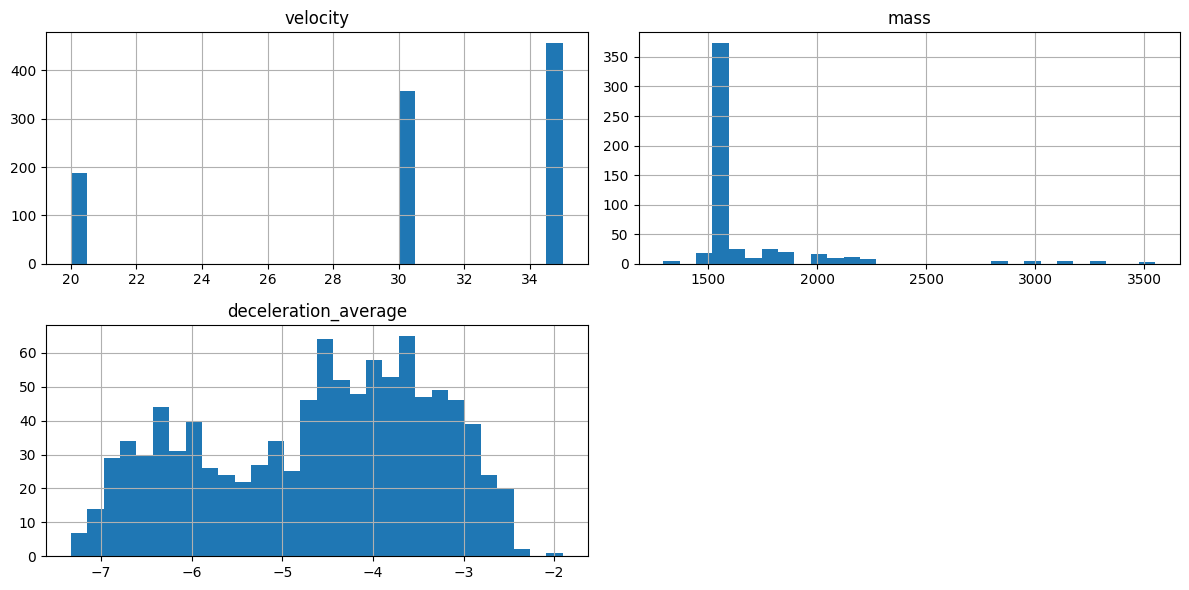

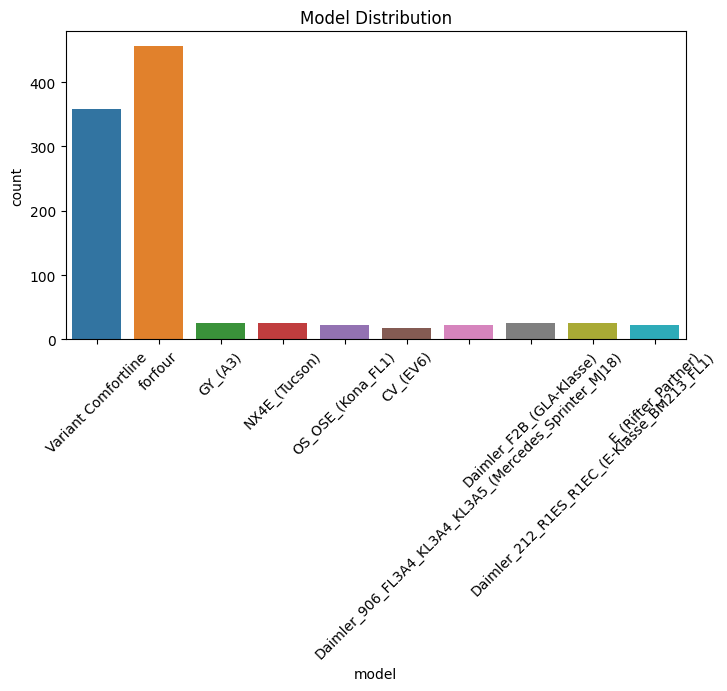

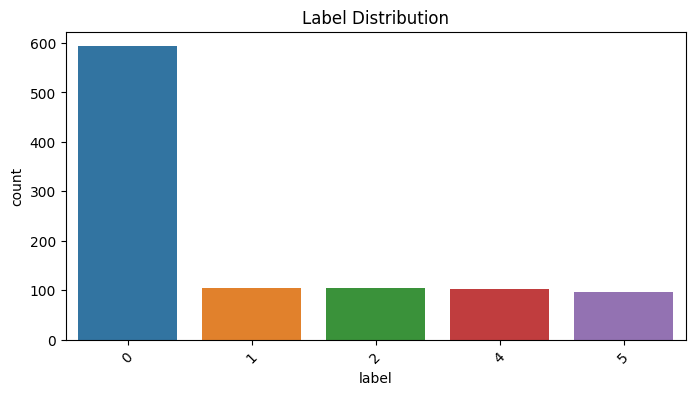

In [18]:
# Plot histograms for numerical features
df[['velocity', 'mass', 'deceleration_average']].hist(figsize=(12, 6), bins=30)
plt.tight_layout()
plt.show()

# Countplot for model distribution
plt.figure(figsize=(8, 4))
sns.countplot(x='model', data=df)
plt.title('Model Distribution')
plt.xticks(rotation=45)
plt.show()

# Countplot for label distribution
plt.figure(figsize=(8, 4))
sns.countplot(x='label', data=df)
plt.title('Label Distribution')
plt.xticks(rotation=45)
plt.show()

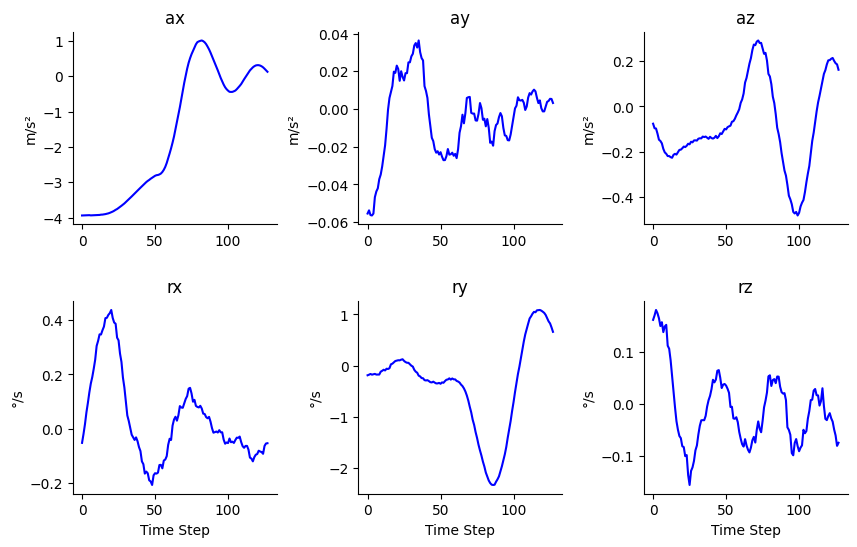

In [19]:
def plot_drive_data(data: np.ndarray) -> None:


    # Labels for the 6 sensor signals
    labels = ['ax', 'ay', 'az', 'rx', 'ry', 'rz']

    # Create figure and 2x3 subplots
    fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(10, 6))

    # Loop over each axis and sensor data to plot
    for i, ax in enumerate(axs.flat):
        # Plot the sensor data (without time)
        ax.plot(data[:, i], color='blue')

        # Set subplot title and axis labels
        ax.set_title(labels[i])
        if i < 3:
            ax.set_ylabel('m/s²')
        else:
            ax.set_ylabel('°/s')

        # Remove top and right borders for cleaner look
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)

        # Add x-axis label for the bottom subplots
        if i >= 3:
            ax.set_xlabel('Time Step')

    # Adjust spaces between subplots
    plt.subplots_adjust(hspace=0.4, wspace=0.4)
    plt.show()
plot_drive_data(df.loc[0,'sensor_data'])

In [20]:
# Version checks
import sklearn
assert sklearn.__version__ >= '1.0', "scikit-learn version must be >= 1.0. Run 'pip install --upgrade scikit-learn'."
import torch
assert torch.__version__ >= '1.10', "PyTorch version must be >= 1.10. Run 'pip install --upgrade torch'."


In [21]:
import sklearn
print(sklearn.__version__)

1.6.1


In [22]:
!pip install --upgrade scikit-learn
!pip install --upgrade imbalanced-learn

  Using cached scikit_learn-1.6.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
Using cached scikit_learn-1.6.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.5 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.0
    Uninstalling scikit-learn-1.7.0:
      Successfully uninstalled scikit-learn-1.7.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.6.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.


In [23]:

import sklearn
print(sklearn.__version__)

1.6.1


In [24]:
!pip install tqdm

Using device: cuda
Loading data...
Preprocessing data...
Balancing data...
Normalizing data...
Preparing datasets and DataLoader...
Input shape: torch.Size([1, 128, 6]), Num classes: 5
CNN2D(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.4, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.4, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (attention): MultiheadAttention(


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/100: Train Loss=1.6428, Train Acc=0.2354, Val Loss=1.7123, Val Acc=0.2099
Epoch 2/100: Train Loss=1.4364, Train Acc=0.3781, Val Loss=1.7307, Val Acc=0.2788
No improvement in val_loss for 1 epoch(s).
Epoch 3/100: Train Loss=1.2806, Train Acc=0.5046, Val Loss=1.7495, Val Acc=0.3514
No improvement in val_loss for 2 epoch(s).
Epoch 4/100: Train Loss=1.1288, Train Acc=0.6075, Val Loss=1.6753, Val Acc=0.2420
Epoch 5/100: Train Loss=1.0102, Train Acc=0.6863, Val Loss=1.5199, Val Acc=0.2876
Epoch 6/100: Train Loss=0.9175, Train Acc=0.7386, Val Loss=1.4038, Val Acc=0.3030
Epoch 7/100: Train Loss=0.8428, Train Acc=0.7758, Val Loss=1.3122, Val Acc=0.3244
Epoch 8/100: Train Loss=0.7735, Train Acc=0.8052, Val Loss=1.2364, Val Acc=0.3678
Epoch 9/100: Train Loss=0.7257, Train Acc=0.8252, Val Loss=1.1727, Val Acc=0.4136
Epoch 10/100: Train Loss=0.6835, Train Acc=0.8407, Val Loss=1.1175, Val Acc=0.4519
Epoch 11/100: Train Loss=0.6427, Train Acc=0.8527, Val Loss=1.0555, Val Acc=0.4956
Epoch 12/1

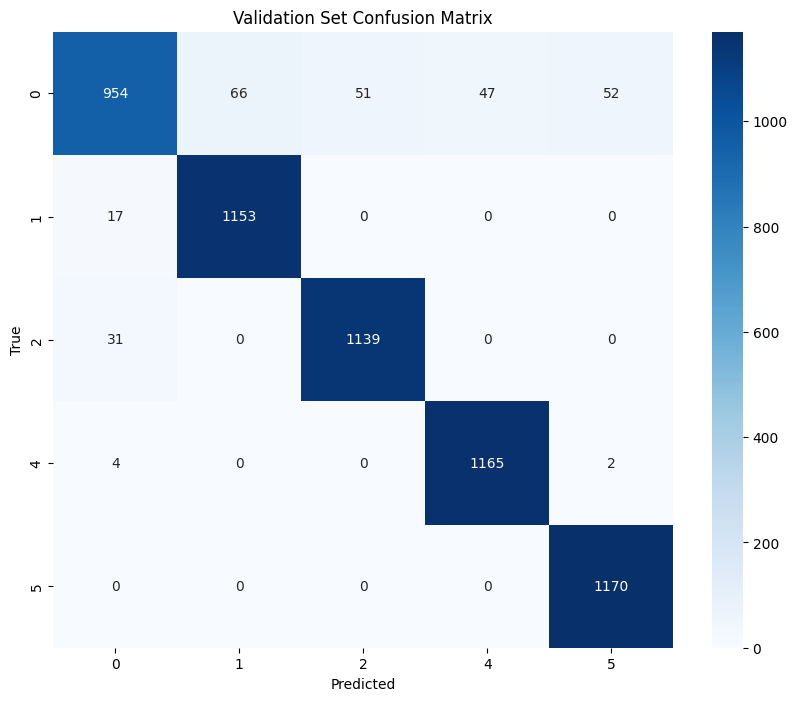

Evaluating on Test set...
=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       0.64      0.87      0.74       593
           1       0.54      0.14      0.23       104
           2       0.89      0.15      0.26       105
           4       0.37      0.39      0.38       103
           5       0.45      0.18      0.25        96

    accuracy                           0.60      1001
   macro avg       0.58      0.35      0.37      1001
weighted avg       0.61      0.60      0.55      1001



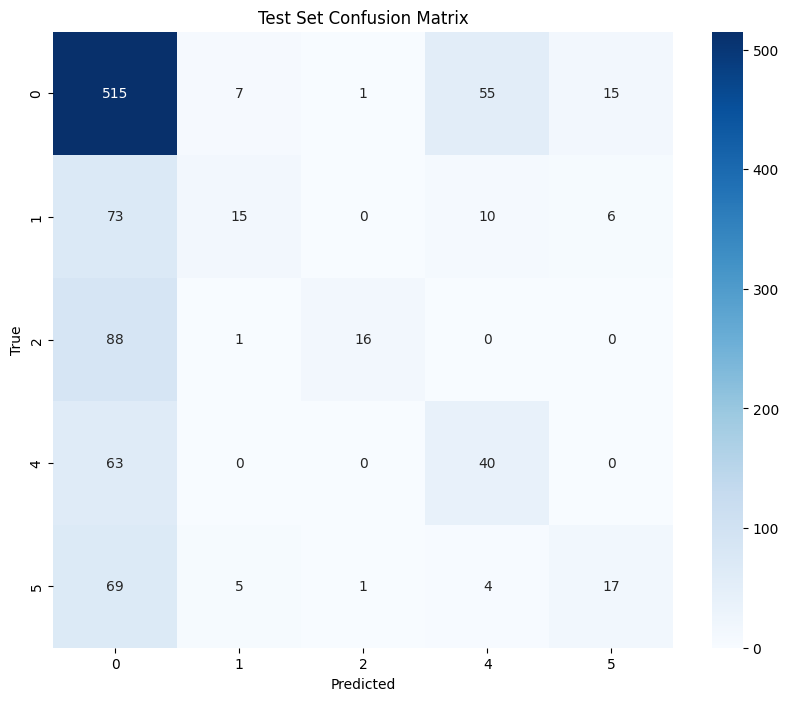

Plotting training curves...


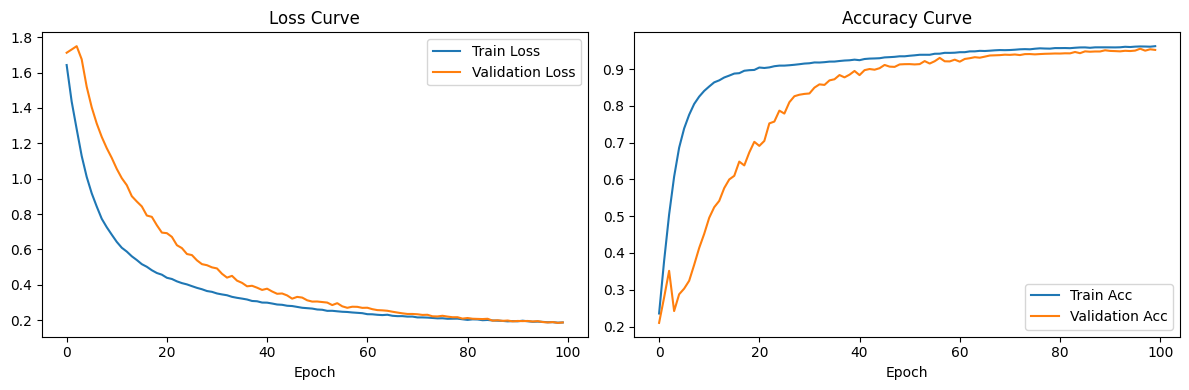

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

# 路径配置，根据实际情况修改
TRAIN_PATH = '../data/train.pickle'
TEST_PATH = '../data/test.pickle'
GAN_PATH = '../data/generated_data.pickle'
MODEL_SAVE = 'brake_diagnosis_2dcnn_pytorch.pth'
META_SAVE = 'meta_pytorch.pkl'

# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==== 1. 加载数据 ====
def load_data():
    # 加载原始训练数据
    with open(TRAIN_PATH, 'rb') as f:
        train_data = pickle.load(f)
    x_train = np.stack(train_data['sensor_data'])
    y_train = np.array(train_data['label'])
    df_train = pd.DataFrame({
        'sensor_data': list(x_train),
        'label': y_train
    })
    
    # 加载GAN生成数据
    with open(GAN_PATH, 'rb') as f:
        gan_data = pickle.load(f)
    x_gan = np.array([item['sensor_data'] for item in gan_data])
    y_gan = np.array([item['label'] for item in gan_data])
    df_gan = pd.DataFrame({
        'sensor_data': list(x_gan),
        'label': y_gan
    })
    
    # 加载测试数据
    with open(TEST_PATH, 'rb') as f:
        test_data = pickle.load(f)
    x_test = np.stack(test_data['sensor_data'])
    y_test = np.array(test_data['label'])
    df_test = pd.DataFrame({
        'sensor_data': list(x_test),
        'label': y_test
    })
    
    return df_train, df_gan, df_test

# ==== 2. 预处理数据 ====
def preprocess_data(df_train, df_test, df_gan=None):
    # 只保留测试集出现的类别
    test_classes = set(df_test['label'].unique())
    train_mask = df_train['label'].isin(test_classes)
    df_train = df_train[train_mask].copy()
    if df_gan is not None:
        gan_mask = df_gan['label'].isin(test_classes)
        df_gan = df_gan[gan_mask].copy()
        # 合并
        df_train = pd.concat([df_train, df_gan], ignore_index=True)
    return df_train, df_test

# ==== 3. 上采样均衡化 ====
def balance_data(df_train):
    # 按 label 上采样到各类别样本数一致
    max_count = df_train['label'].value_counts().max()
    df_list = []
    for label, group in df_train.groupby('label'):
        if len(group) < max_count:
            group_up = resample(group, replace=True, n_samples=max_count, random_state=42)
            df_list.append(group_up)
        else:
            df_list.append(group)
    df_balanced = pd.concat(df_list, ignore_index=True)
    return df_balanced

# ==== 4. 标准化处理 ====
def normalize_data(df_train, df_test):
    # 将 sensor_data 提取为 numpy array
    sensor_train = np.stack(df_train['sensor_data'].values)  # 形状 (N_train, H, W)
    sensor_test = np.stack(df_test['sensor_data'].values)    # 形状 (N_test, H, W)
    
    # 检查 NaN 并填充
    if np.isnan(sensor_train).any():
        warnings.warn("传感器训练数据中包含 NaN，已用 0 填充")
        sensor_train = np.nan_to_num(sensor_train)
    if np.isnan(sensor_test).any():
        warnings.warn("传感器测试数据中包含 NaN，已用 0 填充")
        sensor_test = np.nan_to_num(sensor_test)
    
    # 计算均值和标准差。这里假设 sensor_train 维度 (N, H, W)，逐元素均值/标准差
    # 按照 axis=(0,1,2) 计算全局均值/方差，也可按需保留通道维度，但此处 sensor_data 可能是二维（time × feature），直接全局标准化
    mean = sensor_train.mean(axis=(0,1,2), keepdims=True)  # shape (1,1,1) or broadcastable
    std = sensor_train.std(axis=(0,1,2), keepdims=True)
    std[std == 0] = 1e-8
    
    sensor_train_norm = (sensor_train - mean) / (std + 1e-8)
    sensor_test_norm = (sensor_test - mean) / (std + 1e-8)
    
    # 将归一化结果写回 DataFrame
    df_train = df_train.copy()
    df_test = df_test.copy()
    df_train['sensor_data'] = list(sensor_train_norm)
    df_test['sensor_data'] = list(sensor_test_norm)
    
    # 为保存元信息，返回 mean, std
    return df_train, df_test, mean, std

# ==== 5. 准备数据集和 DataLoader ====
class SensorDataset(Dataset):
    def __init__(self, X_array, y_array):
        """
        X_array: numpy array of形状 (N, H, W)，
        y_array: numpy array of形状 (N,) 整数标签
        """
        self.X = X_array
        self.y = y_array.astype(np.int64)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        x = self.X[idx]  # shape (H, W)
        # 转为 float32 tensor，并添加 channel 维度：(1, H, W)
        x_tensor = torch.from_numpy(x).float().unsqueeze(0)
        y_tensor = torch.tensor(self.y[idx], dtype=torch.long)
        return x_tensor, y_tensor

def prepare_data(df_train, df_test, test_size=0.2, random_state=42):
    # 标签编码
    le = LabelEncoder()
    y_all = le.fit_transform(df_train['label'].astype(str))
    # 测试集标签，也要用同一个 encoder
    y_test = le.transform(df_test['label'].astype(str))
    num_classes = len(le.classes_)
    
    # X 数组
    X_all = np.stack(df_train['sensor_data'].values)  # (N_train, H, W)
    X_test = np.stack(df_test['sensor_data'].values)  # (N_test, H, W)
    
    # 先划分训练/验证
    X_train, X_val, y_train, y_val = train_test_split(
        X_all, y_all, test_size=test_size, random_state=random_state, stratify=y_all
    )
    # 训练集类别权重，用于 CrossEntropyLoss 的 weight 参数
    class_weights = compute_class_weight('balanced', classes=np.arange(num_classes), y=y_train)
    # 转成 torch tensor
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    
    # 构建 Dataset
    train_dataset = SensorDataset(X_train, y_train)
    val_dataset = SensorDataset(X_val, y_val)
    test_dataset = SensorDataset(X_test, y_test)
    
    return train_dataset, val_dataset, test_dataset, le, class_weights_tensor, num_classes

# ==== 6. 定义带多注意力头的 2D-CNN 模型 ====
class CNN2D(nn.Module):
    def __init__(self, input_shape, num_classes, l2_reg=1e-3):
        """
        input_shape: (C, H, W)，这里 C=1
        num_classes: 分类数
        l2_reg: L2 正则化系数，将用于 optimizer.weight_decay
        """
        super(CNN2D, self).__init__()
        # 假设 input_shape = (1, H, W)
        # Conv 层按照 Keras: Conv2D(filters, (3,3), padding='same', kernel_regularizer=l2)
        # PyTorch: padding=1 保持大小
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=(2,1))
        self.drop1 = nn.Dropout(0.4)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=(2,1))
        self.drop2 = nn.Dropout(0.4)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # 多注意力头机制 (Multi-Head Attention)
        self.attention = nn.MultiheadAttention(embed_dim=128, num_heads=8, batch_first=True)
        
        # 全连接层
        self.fc1 = nn.Linear(128, 128)
        self.bn_fc1 = nn.BatchNorm1d(128)
        self.drop_fc1 = nn.Dropout(0.5)
        self.fc_out = nn.Linear(128, num_classes)
        
    def forward(self, x):
        # x: (batch, 1, H, W)
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)
        x = self.drop1(x)
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)
        x = self.drop2(x)
        
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)  # 此时 x 形状: (batch, 128, H', W')
        
        # 为注意力机制准备数据
        B, C, H, W = x.shape  # C=128, H'=H/4 (经过两次池化), W'=W
        x_flat = x.view(B, H * W, C)  # 重塑为 (batch, 序列长度, 特征维度) = (B, H'*W', 128)
        
        # 应用多注意力头机制
        attn_output, _ = self.attention(x_flat, x_flat, x_flat)  # 自注意力
        
        # 在序列维度上取平均 (H'*W')
        x = attn_output.mean(dim=1)  # 形状变为 (batch, 128)
        
        x = self.fc1(x)
        x = self.bn_fc1(x)
        x = F.relu(x)
        x = self.drop_fc1(x)
        
        x = self.fc_out(x)  # logits
        return x

# ==== 7. 训练与验证函数 ====
def train_one_epoch(model, dataloader, criterion, optimizer, device, clip_value=1.0):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in dataloader:
        inputs = inputs.to(device)  # (batch,1,H,W)
        labels = labels.to(device)  # (batch,)
        
        optimizer.zero_grad()
        outputs = model(inputs)  # (batch, num_classes)
        loss = criterion(outputs, labels)
        loss.backward()
        # 梯度裁剪
        torch.nn.utils.clip_grad_value_(model.parameters(), clip_value)
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# ==== 8. 训练主函数，带 Early Stopping & ReduceLROnPlateau ====
def train_model(model, train_dataset, val_dataset, class_weights_tensor,
                batch_size=256, max_epochs=100, patience_es=15, patience_lr=10,
                lr=1e-5, min_lr=1e-7, weight_decay=1e-3, device=device):
    """
    model: 待训练模型
    train_dataset, val_dataset: Dataset 对象
    class_weights_tensor: 用于 CrossEntropyLoss 的 weight
    """
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    
    # 定义损失函数带类别权重
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    # 优化器，Adam + weight_decay 对应 L2 正则
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    # 学习率调度：ReduceLROnPlateau
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=patience_lr, 
                                  verbose=True, min_lr=min_lr)
    
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    for epoch in range(1, max_epochs+1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch}/{max_epochs}: "
              f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
        
        # 调整学习率
        scheduler.step(val_loss)
        
        # Early Stopping 检查
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"No improvement in val_loss for {epochs_no_improve} epoch(s).")
        
        if epochs_no_improve >= patience_es:
            print(f"Early stopping triggered after {epoch} epochs.")
            break
    
    # 恢复到最佳权重
    if best_state is not None:
        model.load_state_dict(best_state)
    return history

# ==== 9. 评估函数 ====
def evaluate_model(model, dataset, le, dataset_name="Dataset", batch_size=256, device=device):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.numpy())
    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    
    # classification report
    if hasattr(le, 'classes_'):
        target_names = le.classes_
    else:
        target_names = [str(i) for i in range(len(np.unique(all_labels)))]
    
    print(f"=== {dataset_name} Set Classification Report ===")
    print(classification_report(all_labels, all_preds, target_names=target_names, zero_division=0))
    
    # 混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'{dataset_name} Set Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# ==== 10. 主函数 ====
def main():
    print("Loading data...")
    df_train, df_gan, df_test = load_data()
    
    print("Preprocessing data...")
    df_train, df_test = preprocess_data(df_train, df_test, df_gan)
    
    print("Balancing data...")
    df_train = balance_data(df_train)
    
    print("Normalizing data...")
    df_train, df_test, sensor_mean, sensor_std = normalize_data(df_train, df_test)
    
    print("Preparing datasets and DataLoader...")
    train_dataset, val_dataset, test_dataset, le, class_weights_tensor, num_classes = prepare_data(df_train, df_test)
    
    # 构造模型
    # 需要确定 input_shape: 从某个样本看 (1, H, W)
    sample_X, _ = train_dataset[0]
    input_shape = sample_X.shape  # (1, H, W)
    print(f"Input shape: {input_shape}, Num classes: {num_classes}")
    model = CNN2D(input_shape, num_classes).to(device)
    print(model)
    
    # 训练
    print("Training model...")
    history = train_model(model, train_dataset, val_dataset, class_weights_tensor)
    
    # 保存模型权重
    print("Saving model...")
    torch.save(model.state_dict(), MODEL_SAVE)
    # 保存元信息：LabelEncoder, mean, std
    meta = {
        'le': le,
        'sensor_mean': sensor_mean,
        'sensor_std': sensor_std
    }
    with open(META_SAVE, 'wb') as f:
        pickle.dump(meta, f)
    # 或者用 joblib.dump(meta, META_SAVE)
    
    # 评估
    print("Evaluating on Validation set...")
    evaluate_model(model, val_dataset, le, dataset_name="Validation")
    print("Evaluating on Test set...")
    evaluate_model(model, test_dataset, le, dataset_name="Test")
    
    # 绘制训练曲线
    print("Plotting training curves...")
    plt.figure(figsize=(12, 4))
    # Loss 曲线
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epoch')
    plt.legend()
    # Accuracy 曲线
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Validation Acc')
    plt.title('Accuracy Curve')
    plt.xlabel('Epoch')
    plt.legend()
    plt.tight_layout()
    plt.savefig('training_curves_pytorch.png')
    plt.show()

if __name__ == '__main__':
    main()

In [ ]:
import os
import pickle
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter

# ===== 路径配置，根据实际环境修改 =====
TRAIN_PATH = '/kaggle/input/finaltask/train.pickle'
TEST_PATH = '/kaggle/input/finaltask/test.pickle'
GAN_PATH = '/kaggle/input/finaltask/generated_data.pickle'
MODEL_SAVE = 'brake_diagnosis_multihead_pytorch.pth'
META_SAVE = 'meta_multihead_pytorch.pkl'

# ==== 全局 class_map，用于 class_id <-> 4-bit 向量映射 ====
# 假设 class_id 范围 0-11，对应 "FL-FR-RL-RR"
class_map = {
    0: [0,0,0,0],
    1: [0,0,1,0],
    2: [0,0,0,1],
    3: [0,0,1,1],
    4: [1,0,0,0],
    5: [0,1,0,0],
    6: [1,1,0,0],
    7: [1,0,1,0],
    8: [0,1,0,1],
    9: [1,0,0,1],
    10:[0,1,1,0],
    11:[1,1,1,1]
}
reverse_map = {tuple(v): k for k,v in class_map.items()}

# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # 若需要可开启以下以获得更确定的行为，但会降低性能
    # torch.backends.cudnn.deterministic = True
    # torch.backends.cudnn.benchmark = False

# ==== 1. 加载数据 ====
def load_data():
    """
    从 pickle 文件加载训练、GAN、测试数据，返回 DataFrame。
    """
    # 加载原始训练数据
    with open(TRAIN_PATH, 'rb') as f:
        train_data = pickle.load(f)
    x_train = np.stack(train_data['sensor_data'])  # (N_train, time, features)
    y_train = np.array(train_data['label'])
    df_train = pd.DataFrame({'sensor_data': list(x_train), 'label': y_train})

    # 加载 GAN 生成数据
    with open(GAN_PATH, 'rb') as f:
        gan_data = pickle.load(f)
    x_gan = np.array([item['sensor_data'] for item in gan_data])
    y_gan = np.array([item['label'] for item in gan_data])
    df_gan = pd.DataFrame({'sensor_data': list(x_gan), 'label': y_gan})

    # 加载测试数据
    with open(TEST_PATH, 'rb') as f:
        test_data = pickle.load(f)
    x_test = np.stack(test_data['sensor_data'])
    y_test = np.array(test_data['label'])
    df_test = pd.DataFrame({'sensor_data': list(x_test), 'label': y_test})

    return df_train, df_gan, df_test

# ==== 2. 预处理数据：保留测试集出现类别 & 合并 GAN ====
def preprocess_data(df_train, df_test, df_gan=None):
    """
    只保留 df_train 和 df_gan 中 label 在 df_test 中出现的类别，然后合并。
    """
    test_classes = set(df_test['label'].unique())
    df_train = df_train[df_train['label'].isin(test_classes)].copy()
    if df_gan is not None:
        df_gan = df_gan[df_gan['label'].isin(test_classes)].copy()
        df_train = pd.concat([df_train, df_gan], ignore_index=True)
    df_train = df_train.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)
    return df_train, df_test

# ==== 3. 上采样均衡化 ====
def balance_data(df_train, random_state=42):
    """
    对 df_train 按 label 做上采样，使各类别样本数相同。
    """
    counts = df_train['label'].value_counts()
    max_count = counts.max()
    df_list = []
    for label, cnt in counts.items():
        df_label = df_train[df_train['label'] == label]
        if cnt < max_count:
            df_up = df_label.sample(n=max_count, replace=True, random_state=random_state)
            df_list.append(df_up)
        else:
            df_list.append(df_label)
    df_bal = pd.concat(df_list, ignore_index=True)
    df_bal = df_bal.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    return df_bal

# ==== 4. 标准化处理 ====
def normalize_data(df_train, df_test):
    """
    对训练和测试 sensor_data 做全局标准化：mean/std 从训练集中计算。
    返回标准化后的 df_train, df_test，以及 mean, std（numpy 数组）。
    """
    sensor_train = np.stack(df_train['sensor_data'].values)  # (N_train, time, features)
    sensor_test = np.stack(df_test['sensor_data'].values)    # (N_test, time, features)
    # 处理 NaN
    if np.isnan(sensor_train).any():
        warnings.warn("NaN in train sensor_data; fill with 0")
        sensor_train = np.nan_to_num(sensor_train)
    if np.isnan(sensor_test).any():
        warnings.warn("NaN in test sensor_data; fill with 0")
        sensor_test = np.nan_to_num(sensor_test)
    # 计算 mean/std，axis=(0,1) 表示对所有样本和时间步一起计算每个特征的统计
    mean = sensor_train.mean(axis=(0,1), keepdims=True)  # shape (1,1,features)
    std = sensor_train.std(axis=(0,1), keepdims=True)
    std[std == 0] = 1e-8
    sensor_train_norm = (sensor_train - mean) / (std + 1e-8)
    sensor_test_norm = (sensor_test - mean) / (std + 1e-8)
    df_train = df_train.copy()
    df_test = df_test.copy()
    df_train['sensor_data'] = list(sensor_train_norm)
    df_test['sensor_data'] = list(sensor_test_norm)
    return df_train, df_test, mean, std

# ==== 5. 准备多标签数据 ====
def prepare_data_multi(df_train, df_test):
    """
    将原始 class_id 标签拆成 4-bit multi-label。
    返回：
      X_full: numpy (N, time, features, 1)
      y_full: numpy (N, 4) binary multi-label
      X_test: numpy (N_test, time, features, 1)
      y_test: numpy (N_test, 4)
      y_full_id: numpy (N,) 原 class_id
      y_test_id: numpy (N_test,)
    """
    y_full_id = df_train['label'].astype(int).values
    y_test_id = df_test['label'].astype(int).values
    # multi-label
    y_full = np.array([class_map[int(cid)] for cid in y_full_id], dtype=np.float32)  # (N,4)
    y_test = np.array([class_map[int(cid)] for cid in y_test_id], dtype=np.float32)  # (N_test,4)
    # X: add channel dim
    def build_2d_sequences(df):
        arr = np.stack(df['sensor_data'].values)  # (N, time, features)
        return arr[..., np.newaxis]               # (N, time, features, 1)
    X_full = build_2d_sequences(df_train)
    X_test = build_2d_sequences(df_test)
    return X_full, y_full, X_test, y_test, y_full_id, y_test_id

# ==== Dataset ====
class Sensor2DDatasetMulti(Dataset):
    def __init__(self, X_array, y_array=None):
        """
        X_array: numpy array (N, time, features, 1)
        y_array: numpy array (N,4) binary labels; 若 None，则只返回 x
        """
        self.X = X_array
        self.y = y_array
        self.has_label = y_array is not None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]  # (time, features, 1)
        # 转为 (1, time, features)
        x = np.transpose(x, (2, 0, 1))  # (1, time, features)
        x_tensor = torch.from_numpy(x).float()
        if self.has_label:
            y = self.y[idx]  # (4,)
            y_tensor = torch.from_numpy(y).float()
            return x_tensor, y_tensor
        else:
            return x_tensor

# ==== 7. 定义多头 2D-CNN 模型 ====
class MultiHeadCNN2D(nn.Module):
    def __init__(self):
        super(MultiHeadCNN2D, self).__init__()
        # Shared CNN part，与 Keras 结构对应
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d((2,1))
        self.drop1 = nn.Dropout(0.4)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d((2,1))
        self.drop2 = nn.Dropout(0.4)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.gap = nn.AdaptiveAvgPool2d((1,1))

        # Dense layers
        self.fc_shared = nn.Linear(128, 128)
        self.bn_fc = nn.BatchNorm1d(128)
        self.drop_fc = nn.Dropout(0.5)
        # 4 heads, each outputs single logit
        self.head_FL = nn.Linear(128, 1)
        self.head_FR = nn.Linear(128, 1)
        self.head_RL = nn.Linear(128, 1)
        self.head_RR = nn.Linear(128, 1)

    def forward(self, x):
        # x: (batch,1,time,features)
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)
        x = self.drop1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)
        x = self.drop2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.gap(x)           # (batch,128,1,1)
        x = x.view(x.size(0), -1) # (batch,128)

        x = self.fc_shared(x)     # (batch,128)
        x = self.bn_fc(x)
        x = F.relu(x)
        x = self.drop_fc(x)
        # Heads
        logit_FL = self.head_FL(x).squeeze(1)  # (batch,)
        logit_FR = self.head_FR(x).squeeze(1)
        logit_RL = self.head_RL(x).squeeze(1)
        logit_RR = self.head_RR(x).squeeze(1)
        logits = torch.stack([logit_FL, logit_FR, logit_RL, logit_RR], dim=1)  # (batch,4)
        return logits  # 未经过 sigmoid

# ==== 8. 训练单个多头模型，记录 Loss 和各 head 准确率 ====
def train_multihead_model(model, train_dataset, val_dataset,
                          batch_size=256, lr=1e-5, weight_decay=1e-3,
                          patience_lr=5, patience_es=10, max_epochs=100):
    """
    训练多头模型，并记录每 epoch 的训练/验证 loss 与各 head 的准确率。
    返回 history 字典，包含：
      - train_loss, val_loss
      - train_acc_FL, train_acc_FR, train_acc_RL, train_acc_RR
      - val_acc_FL,  val_acc_FR,  val_acc_RL,  val_acc_RR
    """
    model.to(device)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=0 if os.getenv('KAGGLE_KERNEL_RUN_TYPE') else 2,
                              pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                              num_workers=0 if os.getenv('KAGGLE_KERNEL_RUN_TYPE') else 2,
                              pin_memory=True)
    criterion = nn.BCEWithLogitsLoss()  # logits (batch,4) vs labels (batch,4)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                                  patience=patience_lr, verbose=True, min_lr=1e-7)

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc_FL': [], 'train_acc_FR': [], 'train_acc_RL': [], 'train_acc_RR': [],
        'val_acc_FL': [],   'val_acc_FR': [],   'val_acc_RL': [],   'val_acc_RR': []
    }

    for epoch in range(1, max_epochs+1):
        # ---- Train ----
        model.train()
        running_loss = 0.0
        correct_counts = np.zeros(4, dtype=np.int64)
        total_count = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)    # (batch,1,time,features)
            labels = labels.to(device)    # (batch,4)
            optimizer.zero_grad()
            logits = model(inputs)        # (batch,4)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_value_(model.parameters(), 1.0)
            optimizer.step()

            bsz = inputs.size(0)
            running_loss += loss.item() * bsz

            # 计算训练集准确率
            with torch.no_grad():
                probs = torch.sigmoid(logits)       # (batch,4)
                preds = (probs >= 0.5).long()       # (batch,4)
                true = labels.long()                # (batch,4)
                for i in range(4):
                    correct_counts[i] += (preds[:,i] == true[:,i]).sum().item()
                total_count += bsz

        train_loss = running_loss / total_count
        train_accs = correct_counts / total_count  # array length 4

        # ---- Validation ----
        model.eval()
        running_val_loss = 0.0
        correct_counts_val = np.zeros(4, dtype=np.int64)
        total_val = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                logits = model(inputs)
                loss = criterion(logits, labels)
                bsz = inputs.size(0)
                running_val_loss += loss.item() * bsz

                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).long()
                true = labels.long()
                for i in range(4):
                    correct_counts_val[i] += (preds[:,i] == true[:,i]).sum().item()
                total_val += bsz

        val_loss = running_val_loss / total_val
        val_accs = correct_counts_val / total_val

        # 记录 history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc_FL'].append(train_accs[0])
        history['train_acc_FR'].append(train_accs[1])
        history['train_acc_RL'].append(train_accs[2])
        history['train_acc_RR'].append(train_accs[3])
        history['val_acc_FL'].append(val_accs[0])
        history['val_acc_FR'].append(val_accs[1])
        history['val_acc_RL'].append(val_accs[2])
        history['val_acc_RR'].append(val_accs[3])

        # 打印本 epoch 信息
        print(f"Epoch {epoch}/{max_epochs}: "
              f"Train Loss={train_loss:.4f}, "
              f"Train Accs=[FL{train_accs[0]:.4f}, FR{train_accs[1]:.4f}, RL{train_accs[2]:.4f}, RR{train_accs[3]:.4f}], "
              f"Val Loss={val_loss:.4f}, "
              f"Val Accs=[FL{val_accs[0]:.4f}, FR{val_accs[1]:.4f}, RL{val_accs[2]:.4f}, RR{val_accs[3]:.4f}]")

        # 学习率调度与 EarlyStopping
        scheduler.step(val_loss)
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"No improvement in val_loss for {epochs_no_improve} epochs")
        if epochs_no_improve >= patience_es:
            print("Early stopping triggered")
            break

    # 恢复最佳权重
    if best_state is not None:
        model.load_state_dict(best_state)
    return history

# ==== 9. 绘制训练曲线，包括 Loss 和 Accuracy ====
def plot_training_history_multihead(history, heads=['FL','FR','RL','RR'], save_path_prefix='training_curves_multihead'):
    """
    history: train_multihead_model 返回的字典，包含 train_loss, val_loss, train_acc_<head>, val_acc_<head>
    heads: 列表，长度4，对应 head 名称
    save_path_prefix: 保存图片文件名前缀
    """
    epochs = len(history['train_loss'])
    plt.figure(figsize=(10,4))
    # Loss 曲线
    plt.subplot(1,2,1)
    plt.plot(range(1, epochs+1), history['train_loss'], label='Train Loss')
    plt.plot(range(1, epochs+1), history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.legend()

    # Accuracy 曲线
    plt.subplot(1,2,2)
    for head in heads:
        key_tr = f"train_acc_{head}"
        key_val = f"val_acc_{head}"
        if key_tr in history and key_val in history:
            plt.plot(range(1, epochs+1), history[key_tr], label=f"Train {head}")
            plt.plot(range(1, epochs+1), history[key_val], '--', label=f"Val {head}")
    plt.xlabel('Epoch'); plt.ylabel('Accuracy')
    plt.title('Accuracy Curve per Head')
    plt.legend(loc='lower right', fontsize='small')

    plt.tight_layout()
    save_path = f"{save_path_prefix}.png"
    plt.savefig(save_path)
    print(f"Training curves saved to {save_path}")
    plt.show()

# ==== 9b. 评估多头模型 ====
def evaluate_multihead_model(model, dataset, y_id_true=None, le_classes=None, dataset_name="Dataset", batch_size=256):
    """
    评估多头模型：
    - Per-head: Accuracy, F1
    - 如果提供 y_id_true 和 le_classes，则进行 class-level 报告和混淆矩阵
    Returns: y_bin_pred (numpy (N,4))
    """
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=0 if os.getenv('KAGGLE_KERNEL_RUN_TYPE') else 2,
                        pin_memory=True)
    model.eval()
    all_logits = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            logits = model(inputs)  # (batch,4)
            all_logits.append(logits.cpu().numpy())
            all_labels.append(labels.numpy())
    all_logits = np.concatenate(all_logits, axis=0)  # (N,4)
    all_labels = np.concatenate(all_labels, axis=0)  # (N,4)
    # 计算概率与二值预测
    prob_mat = torch.sigmoid(torch.from_numpy(all_logits)).numpy()  # (N,4)
    y_bin_pred = (prob_mat >= 0.5).astype(int)
    # Per-head metrics
    print(f"=== {dataset_name} Multi-head Per-output Metrics ===")
    heads = ['FL','FR','RL','RR']
    for idx, head in enumerate(heads):
        acc = accuracy_score(all_labels[:,idx], y_bin_pred[:,idx])
        f1 = f1_score(all_labels[:,idx], y_bin_pred[:,idx], zero_division=0)
        print(f"{head}: Acc={acc:.4f}, F1={f1:.4f}")
    # Class-level 报告
    if y_id_true is not None and le_classes is not None:
        y_pred_id = []
        for vec in y_bin_pred:
            cid = reverse_map.get(tuple(vec.tolist()), None)
            if cid is None:
                cid = 0
            y_pred_id.append(cid)
        y_pred_id = np.array(y_pred_id)
        y_true_id = np.array(y_id_true)
        num_classes = len(le_classes)
        labels = list(range(num_classes))
        print(f"=== {dataset_name} Class-level Report ===")
        print(classification_report(
            y_true_id, y_pred_id,
            labels=labels,
            target_names=le_classes,
            zero_division=0
        ))
        cm = confusion_matrix(y_true_id, y_pred_id, labels=labels)
        plt.figure(figsize=(10,8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=le_classes, yticklabels=le_classes)
        plt.title(f"{dataset_name} Class-level Confusion Matrix")
        plt.xlabel("Predicted"); plt.ylabel("True")
        plt.show()
        overall_acc = accuracy_score(y_true_id, y_pred_id)
        overall_f1 = f1_score(y_true_id, y_pred_id, average='macro', zero_division=0)
        print(f"{dataset_name} Overall class Acc={overall_acc:.4f}, Macro F1={overall_f1:.4f}")
    return y_bin_pred

# ==== 10. 多模型投票集成 ====
def ensemble_multihead_predictions(models, X_numpy, voting='soft', batch_size=256):
    """
    models: list of 已训练好的 PyTorch 多头模型
    X_numpy: numpy (N, time, features, 1)
    voting:
      'soft': 对每个 head sigmoid 后概率平均，再 threshold 0.5
      'hard': 对每个 head sigmoid 后 threshold 0.5 得二值，再多数投票（tie -> 1）
    返回 y_bin_ens: numpy (N,4)
    """
    dataset = Sensor2DDatasetMulti(X_numpy, y_array=None)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=0 if os.getenv('KAGGLE_KERNEL_RUN_TYPE') else 2,
                        pin_memory=True)
    n_models = len(models)
    if voting == 'soft':
        sum_probs = None
        for model in models:
            model.eval()
            probs_list = []
            with torch.no_grad():
                for inputs in loader:
                    inputs = inputs.to(device)
                    logits = model(inputs)         # (batch,4)
                    prob = torch.sigmoid(logits).cpu().numpy()  # (batch,4)
                    probs_list.append(prob)
            probs_model = np.concatenate(probs_list, axis=0)  # (N,4)
            if sum_probs is None:
                sum_probs = probs_model
            else:
                sum_probs += probs_model
        avg_probs = sum_probs / n_models
        y_bin_ens = (avg_probs >= 0.5).astype(int)
    else:  # hard voting
        all_bins = []
        for model in models:
            model.eval()
            bins_list = []
            with torch.no_grad():
                for inputs in loader:
                    inputs = inputs.to(device)
                    logits = model(inputs)
                    prob = torch.sigmoid(logits).cpu().numpy()  # (batch,4)
                    bins = (prob >= 0.5).astype(int)
                    bins_list.append(bins)
            bins_model = np.concatenate(bins_list, axis=0)  # (N,4)
            all_bins.append(bins_model)
        all_bins = np.stack(all_bins, axis=0)  # (n_models, N, 4)
        N = all_bins.shape[1]
        y_bin_ens = np.zeros((N,4), dtype=int)
        for i in range(N):
            for j in range(4):
                votes = all_bins[:,i,j]
                cnt = Counter(votes)
                ones = cnt.get(1,0)
                zeros = cnt.get(0,0)
                y_bin_ens[i,j] = 1 if ones >= zeros else 0
    return y_bin_ens

# ==== 11. 报告 ensemble 结果 ====
def report_ensemble(y_bin_pred, y_true_id, le_classes, title):
    """
    y_bin_pred: (N,4) 二值 multi-head 预测
    y_true_id: (N,) 原 class_id
    le_classes: list of class 名称，长度 num_classes
    title: str, 报告标题
    """
    y_pred_id = []
    for vec in y_bin_pred:
        cid = reverse_map.get(tuple(vec.tolist()), None)
        if cid is None:
            cid = 0
        y_pred_id.append(cid)
    y_pred_id = np.array(y_pred_id)
    y_true_id = np.array(y_true_id)
    num_classes = len(le_classes)
    labels = list(range(num_classes))
    print(f"=== {title} Class-level Report ===")
    print(classification_report(
        y_true_id, y_pred_id,
        labels=labels,
        target_names=le_classes,
        zero_division=0
    ))
    cm = confusion_matrix(y_true_id, y_pred_id, labels=labels)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le_classes, yticklabels=le_classes)
    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.show()
    acc = accuracy_score(y_true_id, y_pred_id)
    f1 = f1_score(y_true_id, y_pred_id, average='macro', zero_division=0)
    print(f"{title} Overall Acc={acc:.4f}, Macro F1={f1:.4f}")

# ==== 12. 主流程 ====
def main():
    set_seed(42)
    # 1. 加载
    print("Loading data...")
    df_train, df_gan, df_test = load_data()
    # 2. 预处理
    print("Preprocessing data...")
    df_train, df_test = preprocess_data(df_train, df_test, df_gan)
    # 3. 上采样均衡
    print("Balancing data...")
    df_train = balance_data(df_train)
    # 4. 标准化
    print("Normalizing data...")
    df_train, df_test, sensor_mean, sensor_std = normalize_data(df_train, df_test)
    # 5. 准备多标签数据
    print("Preparing multi-label data...")
    X_full, y_full, X_test, y_test, y_full_id, y_test_id = prepare_data_multi(df_train, df_test)
    # class 名称列表，用于报告
    num_classes = 12
    le_classes = [f"Class_{i}" for i in range(num_classes)]
    print("Full train samples:", len(y_full), "Test samples:", len(y_test))

    # 6. 多次随机分割训练并收集模型用于 ensemble
    n_splits = 5
    models_split = []
    print("Training multiple splits for ensemble...")
    for i in range(n_splits):
        print(f"Split {i+1}/{n_splits}")
        # stratify by y_full_id
        X_tr, X_val, y_tr_multi, y_val_multi, y_tr_id, y_val_id = train_test_split(
            X_full, y_full, y_full_id, test_size=0.2, random_state=42+i, stratify=y_full_id
        )
        train_dataset = Sensor2DDatasetMulti(X_tr, y_tr_multi)
        val_dataset = Sensor2DDatasetMulti(X_val, y_val_multi)
        model = MultiHeadCNN2D().to(device)
        history = train_multihead_model(
            model, train_dataset, val_dataset,
            batch_size=256, lr=1e-5, weight_decay=1e-3,
            patience_lr=5, patience_es=10, max_epochs=100
        )
        models_split.append(model)
        # 验证集评估 per-head
        print(f"Validation Split {i+1} evaluation:")
        evaluate_multihead_model(model, val_dataset, y_id_true=None, le_classes=None,
                                 dataset_name=f"Val Split {i+1}")
        # 可选：绘制该 split 的训练曲线
        plot_training_history_multihead(history, heads=['FL','FR','RL','RR'],
                                        save_path_prefix=f"training_curves_split{i+1}")

    # 7. 在测试集上 ensemble 投票
    print("Ensembling on Test set...")
    y_bin_soft = ensemble_multihead_predictions(models_split, X_test, voting='soft', batch_size=256)
    y_bin_hard = ensemble_multihead_predictions(models_split, X_test, voting='hard', batch_size=256)
    # Soft voting 评估
    print("Soft Voting Ensemble Evaluation:")
    report_ensemble(y_bin_soft, y_test_id, le_classes, "Test Soft Voting Ensemble")
    for idx, head in enumerate(['FL','FR','RL','RR']):
        acc_h = accuracy_score(y_test[:,idx], y_bin_soft[:,idx])
        f1_h = f1_score(y_test[:,idx], y_bin_soft[:,idx], zero_division=0)
        print(f"Soft Voting Head {head}: Acc={acc_h:.4f}, F1={f1_h:.4f}")
    # Hard voting 评估
    print("Hard Voting Ensemble Evaluation:")
    report_ensemble(y_bin_hard, y_test_id, le_classes, "Test Hard Voting Ensemble")
    for idx, head in enumerate(['FL','FR','RL','RR']):
        acc_h = accuracy_score(y_test[:,idx], y_bin_hard[:,idx])
        f1_h = f1_score(y_test[:,idx], y_bin_hard[:,idx], zero_division=0)
        print(f"Hard Voting Head {head}: Acc={acc_h:.4f}, F1={f1_h:.4f}")

    # 8. 训练最终单模型作对比
    print("Training final single multi-head model...")
    X_tr, X_val, y_tr_multi, y_val_multi, y_tr_id, y_val_id = train_test_split(
        X_full, y_full, y_full_id, test_size=0.2, random_state=42, stratify=y_full_id
    )
    train_dataset = Sensor2DDatasetMulti(X_tr, y_tr_multi)
    val_dataset = Sensor2DDatasetMulti(X_val, y_val_multi)
    model_final = MultiHeadCNN2D().to(device)
    history_final = train_multihead_model(
        model_final, train_dataset, val_dataset,
        batch_size=256, lr=1e-5, weight_decay=1e-3,
        patience_lr=5, patience_es=10, max_epochs=100
    )
    # 绘制最终模型训练曲线
    plot_training_history_multihead(history_final, heads=['FL','FR','RL','RR'],
                                    save_path_prefix="training_curves_final_multihead")
    # 在测试集评估单模型
    print("Single Model Evaluation on Test:")
    test_dataset = Sensor2DDatasetMulti(X_test, y_test)
    y_bin_final = evaluate_multihead_model(model_final, test_dataset,
                                           y_id_true=y_test_id, le_classes=le_classes,
                                           dataset_name="Test Single Model")
    for idx, head in enumerate(['FL','FR','RL','RR']):
        acc_f = accuracy_score(y_test[:,idx], y_bin_final[:,idx])
        f1_f = f1_score(y_test[:,idx], y_bin_final[:,idx], zero_division=0)
        print(f"Single Model Head {head}: Acc={acc_f:.4f}, F1={f1_f:.4f}")

    # 9. 保存最终单模型和 meta
    print("Saving final model and metadata...")
    torch.save(model_final.state_dict(), MODEL_SAVE)
    meta = {
        'sensor_mean': sensor_mean,
        'sensor_std': sensor_std,
        'class_map': class_map,
        'reverse_map': reverse_map
    }
    with open(META_SAVE, 'wb') as f:
        pickle.dump(meta, f)

if __name__ == "__main__":
    main()


In [ ]:
# 假设前面已定义好：device, Sensor2DDatasetMulti, MultiHeadCNN2D, evaluate_multihead_model, etc.

# ==== 8. 修改后的训练单个多头模型，记录准确率 ====
def train_multihead_model(model, train_dataset, val_dataset,
                          batch_size=256, lr=1e-5, weight_decay=1e-3,
                          patience_lr=5, patience_es=10, max_epochs=100):
    """
    训练多头模型，并记录每 epoch 的训练/验证 loss 与各 head 准确率。
    返回 history 字典，包含：
      - train_loss, val_loss
      - train_acc_FL, train_acc_FR, train_acc_RL, train_acc_RR
      - val_acc_FL, val_acc_FR, val_acc_RL, val_acc_RR
    """
    model.to(device)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=0 if os.getenv('KAGGLE_KERNEL_RUN_TYPE') else 2,
                              pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                              num_workers=0 if os.getenv('KAGGLE_KERNEL_RUN_TYPE') else 2,
                              pin_memory=True)
    criterion = nn.BCEWithLogitsLoss()  # logits shape (batch,4) vs labels (batch,4)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                                  patience=patience_lr, verbose=True, min_lr=1e-7)

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    # 初始化 history
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc_FL': [], 'train_acc_FR': [], 'train_acc_RL': [], 'train_acc_RR': [],
        'val_acc_FL': [], 'val_acc_FR': [], 'val_acc_RL': [], 'val_acc_RR': []
    }

    for epoch in range(1, max_epochs+1):
        # ---- Train ----
        model.train()
        running_loss = 0.0
        # 累积正确数与总数，用于计算准确率
        correct_counts = np.zeros(4, dtype=np.int64)
        total_count = 0

        for inputs, labels in train_loader:
            # inputs: (batch,1,time,features), labels: (batch,4)
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            logits = model(inputs)  # (batch,4)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_value_(model.parameters(), 1.0)
            optimizer.step()

            # 累积 loss
            bsz = inputs.size(0)
            running_loss += loss.item() * bsz

            # 计算准确率：sigmoid->binary
            with torch.no_grad():
                probs = torch.sigmoid(logits)  # (batch,4)
                preds = (probs >= 0.5).long()  # (batch,4)
                # labels 二值 float，转为 long 比较
                true = labels.long()  # (batch,4)
                # per-head correct
                for i in range(4):
                    correct_counts[i] += (preds[:,i] == true[:,i]).sum().item()
                total_count += bsz

        train_loss = running_loss / total_count
        # per-head train accuracy
        train_accs = correct_counts / total_count  # array length 4

        # ---- Validation ----
        model.eval()
        running_val_loss = 0.0
        correct_counts_val = np.zeros(4, dtype=np.int64)
        total_val = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                logits = model(inputs)
                loss = criterion(logits, labels)
                bsz = inputs.size(0)
                running_val_loss += loss.item() * bsz

                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).long()
                true = labels.long()
                for i in range(4):
                    correct_counts_val[i] += (preds[:,i] == true[:,i]).sum().item()
                total_val += bsz

        val_loss = running_val_loss / total_val
        val_accs = correct_counts_val / total_val

        # 记录 history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc_FL'].append(train_accs[0])
        history['train_acc_FR'].append(train_accs[1])
        history['train_acc_RL'].append(train_accs[2])
        history['train_acc_RR'].append(train_accs[3])
        history['val_acc_FL'].append(val_accs[0])
        history['val_acc_FR'].append(val_accs[1])
        history['val_acc_RL'].append(val_accs[2])
        history['val_acc_RR'].append(val_accs[3])

        # 打印本 epoch 信息
        print(f"Epoch {epoch}/{max_epochs}: "
              f"Train Loss={train_loss:.4f}, "
              f"Train Accs=[FL{train_accs[0]:.4f}, FR{train_accs[1]:.4f}, RL{train_accs[2]:.4f}, RR{train_accs[3]:.4f}], "
              f"Val Loss={val_loss:.4f}, "
              f"Val Accs=[FL{val_accs[0]:.4f}, FR{val_accs[1]:.4f}, RL{val_accs[2]:.4f}, RR{val_accs[3]:.4f}]")

        # 学习率调度、EarlyStopping
        scheduler.step(val_loss)
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            # 可打印等待信息
            print(f"No improvement in val_loss for {epochs_no_improve} epochs")
        if epochs_no_improve >= patience_es:
            print("Early stopping triggered")
            break

    # 恢复最佳权重
    if best_state is not None:
        model.load_state_dict(best_state)
    return history

# ==== 10. 绘制训练曲线，包括 Loss 和 Accuracy ====
def plot_training_history_multihead(history, heads=['FL','FR','RL','RR'], save_path_prefix='training_curves_multihead'):
    """
    history: train_multihead_model 返回的字典，包含 train_loss, val_loss, train_acc_<head>, val_acc_<head>
    heads: 列表，长度4，对应 head 名称和 history 字段后缀
    save_path_prefix: 保存图片文件名前缀
    """
    epochs = len(history['train_loss'])
    # 1. Loss 曲线
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(range(1, epochs+1), history['train_loss'], label='Train Loss')
    plt.plot(range(1, epochs+1), history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.legend()
    # 2. Accuracy 曲线：4 个 head
    plt.subplot(1,2,2)
    for head in heads:
        key_tr = f"train_acc_{head}"
        key_val = f"val_acc_{head}"
        if key_tr in history and key_val in history:
            plt.plot(range(1, epochs+1), history[key_tr], label=f"Train {head}")
            plt.plot(range(1, epochs+1), history[key_val], '--', label=f"Val {head}")
    plt.xlabel('Epoch'); plt.ylabel('Accuracy')
    plt.title('Accuracy Curve per Head')
    plt.legend(loc='lower right', fontsize='small')
    plt.tight_layout()
    # 保存图片
    save_path = f"{save_path_prefix}.png"
    plt.savefig(save_path)
    print(f"Training curves saved to {save_path}")
    plt.show()

# ==== 12. 在主流程中调用示例 ====
def main():
    set_seed(42)
    # 1. 加载、预处理、平衡、标准化、准备 multi-label 等，如前所示...
    print("Loading data...")
    df_train, df_gan, df_test = load_data()
    print("Preprocessing...")
    df_train, df_test = preprocess_data(df_train, df_test, df_gan)
    print("Balancing...")
    df_train = balance_data(df_train)
    print("Normalizing...")
    df_train, df_test, sensor_mean, sensor_std = normalize_data(df_train, df_test)
    print("Preparing multi-label data...")
    X_full, y_full, X_test, y_test, y_full_id, y_test_id = prepare_data_multi(df_train, df_test)
    le_classes = [f"Class_{i}" for i in range(12)]

    # 多次分割并训练 ensemble，如前所示...
    n_splits = 5
    models_split = []
    for i in range(n_splits):
        print(f"Split {i+1}/{n_splits}")
        # stratify by y_full_id
        X_tr, X_val, y_tr_multi, y_val_multi, y_tr_id, y_val_id = train_test_split(
            X_full, y_full, y_full_id, test_size=0.2, random_state=42+i, stratify=y_full_id
        )
        train_dataset = Sensor2DDatasetMulti(X_tr, y_tr_multi)
        val_dataset = Sensor2DDatasetMulti(X_val, y_val_multi)
        model = MultiHeadCNN2D().to(device)
        history = train_multihead_model(model, train_dataset, val_dataset,
                                        batch_size=256, lr=1e-5, weight_decay=1e-3,
                                        patience_lr=5, patience_es=10, max_epochs=100)
        models_split.append(model)
        print(f"Validation Split {i+1} evaluation:")
        evaluate_multihead_model(model, val_dataset, y_id_true=None, le_classes=None,
                                 dataset_name=f"Val Split {i+1}")

        # 绘制该 split 的训练曲线（可选）
        plot_training_history_multihead(history, heads=['FL','FR','RL','RR'],
                                        save_path_prefix=f"training_curves_split{i+1}")

    # 在测试集 ensemble，如前所示...
    print("Ensembling on Test set...")
    y_bin_soft = ensemble_multihead_predictions(models_split, X_test, voting='soft', batch_size=256)
    y_bin_hard = ensemble_multihead_predictions(models_split, X_test, voting='hard', batch_size=256)
    print("Soft Voting Ensemble Evaluation:")
    report_ensemble(y_bin_soft, y_test_id, le_classes, "Test Soft Voting Ensemble")
    for idx, head in enumerate(['FL','FR','RL','RR']):
        acc_h = accuracy_score(y_test[:,idx], y_bin_soft[:,idx])
        f1_h = f1_score(y_test[:,idx], y_bin_soft[:,idx], zero_division=0)
        print(f"Soft Voting Head {head}: Acc={acc_h:.4f}, F1={f1_h:.4f}")
    print("Hard Voting Ensemble Evaluation:")
    report_ensemble(y_bin_hard, y_test_id, le_classes, "Test Hard Voting Ensemble")
    for idx, head in enumerate(['FL','FR','RL','RR']):
        acc_h = accuracy_score(y_test[:,idx], y_bin_hard[:,idx])
        f1_h = f1_score(y_test[:,idx], y_bin_hard[:,idx], zero_division=0)
        print(f"Hard Voting Head {head}: Acc={acc_h:.4f}, F1={f1_h:.4f}")

    # 训练最终单模型
    print("Training final single multi-head model...")
    X_tr, X_val, y_tr_multi, y_val_multi, y_tr_id, y_val_id = train_test_split(
        X_full, y_full, y_full_id, test_size=0.2, random_state=42, stratify=y_full_id
    )
    train_dataset = Sensor2DDatasetMulti(X_tr, y_tr_multi)
    val_dataset = Sensor2DDatasetMulti(X_val, y_val_multi)
    model_final = MultiHeadCNN2D().to(device)
    history_final = train_multihead_model(model_final, train_dataset, val_dataset,
                                          batch_size=256, lr=1e-5, weight_decay=1e-3,
                                          patience_lr=5, patience_es=10, max_epochs=100)
    # 绘制最终模型训练曲线
    plot_training_history_multihead(history_final, heads=['FL','FR','RL','RR'],
                                    save_path_prefix="training_curves_final_multihead")
    # 评估最终模型
    print("Single Model Evaluation on Test:")
    test_dataset = Sensor2DDatasetMulti(X_test, y_test)
    y_bin_final = evaluate_multihead_model(model_final, test_dataset,
                                           y_id_true=y_test_id, le_classes=le_classes,
                                           dataset_name="Test Single Model")
    for idx, head in enumerate(['FL','FR','RL','RR']):
        acc_f = accuracy_score(y_test[:,idx], y_bin_final[:,idx])
        f1_f = f1_score(y_test[:,idx], y_bin_final[:,idx], zero_division=0)
        print(f"Single Model Head {head}: Acc={acc_f:.4f}, F1={f1_f:.4f}")

    # 保存最终模型和 meta
    print("Saving final model and metadata...")
    torch.save(model_final.state_dict(), MODEL_SAVE)
    meta = {'sensor_mean': sensor_mean, 'sensor_std': sensor_std,
            'class_map': class_map, 'reverse_map': reverse_map}
    with open(META_SAVE, 'wb') as f:
        pickle.dump(meta, f)

if __name__ == "__main__":
    main()


In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter
import random

# ===== 路径配置，根据实际环境修改 =====
TRAIN_PATH = '/kaggle/input/finaltask/train.pickle'
TEST_PATH = '/kaggle/input/finaltask/test.pickle'
GAN_PATH = '/kaggle/input/finaltask/generated_data.pickle'
MODEL_SAVE = 'brake_diagnosis_multihead_pytorch.pth'
META_SAVE = 'meta_multihead_pytorch.pkl'

# ==== 全局 class_map，用于 class_id <-> 4-bit 向量映射 ====
# 假设 class_id 范围 0-11，对应 "FL-FR-RL-RR"
class_map = {
    0: [0,0,0,0],
    1: [0,0,1,0],
    2: [0,0,0,1],
    3: [0,0,1,1],
    4: [1,0,0,0],
    5: [0,1,0,0],
    6: [1,1,0,0],
    7: [1,0,1,0],
    8: [0,1,0,1],
    9: [1,0,0,1],
    10:[0,1,1,0],
    11:[1,1,1,1]
}
reverse_map = {tuple(v): k for k,v in class_map.items()}

# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # torch.backends.cudnn.deterministic = True
    # torch.backends.cudnn.benchmark = False

# ==== 1. 加载数据 ====
def load_data():
    # 加载原始训练数据
    with open(TRAIN_PATH, 'rb') as f:
        train_data = pickle.load(f)
    x_train = np.stack(train_data['sensor_data'])  # (N_train, time, features)
    y_train = np.array(train_data['label'])
    df_train = pd.DataFrame({'sensor_data': list(x_train), 'label': y_train})

    # 加载 GAN 数据
    with open(GAN_PATH, 'rb') as f:
        gan_data = pickle.load(f)
    x_gan = np.array([item['sensor_data'] for item in gan_data])
    y_gan = np.array([item['label'] for item in gan_data])
    df_gan = pd.DataFrame({'sensor_data': list(x_gan), 'label': y_gan})

    # 加载测试数据
    with open(TEST_PATH, 'rb') as f:
        test_data = pickle.load(f)
    x_test = np.stack(test_data['sensor_data'])
    y_test = np.array(test_data['label'])
    df_test = pd.DataFrame({'sensor_data': list(x_test), 'label': y_test})

    return df_train, df_gan, df_test

# ==== 2. 预处理数据：保留测试集中出现类别 & 合并 GAN ====
def preprocess_data(df_train, df_test, df_gan=None):
    test_classes = set(df_test['label'].unique())
    df_train = df_train[df_train['label'].isin(test_classes)].copy()
    if df_gan is not None:
        df_gan = df_gan[df_gan['label'].isin(test_classes)].copy()
        df_train = pd.concat([df_train, df_gan], ignore_index=True)
    df_train = df_train.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)
    return df_train, df_test

# ==== 3. 上采样均衡化 ====
def balance_data(df_train, random_state=42):
    counts = df_train['label'].value_counts()
    max_count = counts.max()
    df_list = []
    for label, cnt in counts.items():
        df_label = df_train[df_train['label'] == label]
        if cnt < max_count:
            df_up = df_label.sample(n=max_count, replace=True, random_state=random_state)
            df_list.append(df_up)
        else:
            df_list.append(df_label)
    df_bal = pd.concat(df_list, ignore_index=True)
    df_bal = df_bal.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    return df_bal

# ==== 4. 标准化处理 ====
def normalize_data(df_train, df_test):
    sensor_train = np.stack(df_train['sensor_data'].values)  # (N_train, time, features)
    sensor_test = np.stack(df_test['sensor_data'].values)    # (N_test, time, features)
    # 处理 NaN
    if np.isnan(sensor_train).any():
        warnings.warn("NaN in train sensor_data; fill 0")
        sensor_train = np.nan_to_num(sensor_train)
    if np.isnan(sensor_test).any():
        warnings.warn("NaN in test sensor_data; fill 0")
        sensor_test = np.nan_to_num(sensor_test)
    # 计算全局 mean/std
    mean = sensor_train.mean(axis=(0,1), keepdims=True)  # shape (1,1,features)
    std = sensor_train.std(axis=(0,1), keepdims=True)
    std[std == 0] = 1e-8
    sensor_train_norm = (sensor_train - mean)/(std + 1e-8)
    sensor_test_norm = (sensor_test - mean)/(std + 1e-8)
    df_train = df_train.copy()
    df_test = df_test.copy()
    df_train['sensor_data'] = list(sensor_train_norm)
    df_test['sensor_data'] = list(sensor_test_norm)
    return df_train, df_test, mean, std

# ==== 5. 准备多标签数据 ====
def prepare_data_multi(df_train, df_test):
    """
    返回:
      X_full: numpy (N, time, features, 1)
      y_full: numpy (N, 4) 二值 multi-label
      X_test: numpy (N_test, time, features, 1)
      y_test: numpy (N_test, 4)
      y_full_id: numpy (N,) 原 class_id
      y_test_id: numpy (N_test,)
    """
    # 原 class_id
    y_full_id = df_train['label'].astype(int).values
    y_test_id = df_test['label'].astype(int).values
    # multi-label
    y_full = np.array([class_map[int(cid)] for cid in y_full_id], dtype=np.float32)  # (N,4)
    y_test = np.array([class_map[int(cid)] for cid in y_test_id], dtype=np.float32)
    # X: add channel dim
    def build_2d_sequences(df):
        arr = np.stack(df['sensor_data'].values)  # (N, time, features)
        return arr[..., np.newaxis]               # (N, time, features, 1)
    X_full = build_2d_sequences(df_train)
    X_test = build_2d_sequences(df_test)
    return X_full, y_full, X_test, y_test, y_full_id, y_test_id

# ==== Dataset ====
class Sensor2DDatasetMulti(Dataset):
    def __init__(self, X_array, y_array=None):
        """
        X_array: numpy array (N, time, features, 1)
        y_array: numpy array (N,4) binary labels; 若 None，则只返回 x
        """
        self.X = X_array
        self.y = y_array
        self.has_label = y_array is not None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]  # shape (time, features,1)
        # 转为 (1, time, features)
        x = np.transpose(x, (2, 0, 1))  # (1, time, features)
        x_tensor = torch.from_numpy(x).float()
        if self.has_label:
            y = self.y[idx]  # shape (4,)
            y_tensor = torch.from_numpy(y).float()  # BCEWithLogitsLoss 需要 float
            return x_tensor, y_tensor
        else:
            return x_tensor

# ==== 7. 定义多头 2D-CNN 模型 ====
class MultiHeadCNN2D(nn.Module):
    def __init__(self):
        super(MultiHeadCNN2D, self).__init__()
        # Shared CNN part, 与 Keras 结构对应
        # 输入 channels=1
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d((2,1))
        self.drop1 = nn.Dropout(0.4)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d((2,1))
        self.drop2 = nn.Dropout(0.4)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        # GlobalAveragePooling2D -> AdaptiveAvgPool2d((1,1))
        self.gap = nn.AdaptiveAvgPool2d((1,1))

        # Dense layers
        self.fc_shared = nn.Linear(128, 128)
        self.bn_fc = nn.BatchNorm1d(128)
        self.drop_fc = nn.Dropout(0.5)
        # 4 heads, each outputs single logit
        self.head_FL = nn.Linear(128, 1)
        self.head_FR = nn.Linear(128, 1)
        self.head_RL = nn.Linear(128, 1)
        self.head_RR = nn.Linear(128, 1)

    def forward(self, x):
        # x: (batch,1,time,features)
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)
        x = self.drop1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)
        x = self.drop2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.gap(x)           # (batch,128,1,1)
        x = x.view(x.size(0), -1) # (batch,128)

        x = self.fc_shared(x)     # (batch,128)
        x = self.bn_fc(x)
        x = F.relu(x)
        x = self.drop_fc(x)
        # Heads
        logit_FL = self.head_FL(x).squeeze(1)  # (batch,)
        logit_FR = self.head_FR(x).squeeze(1)
        logit_RL = self.head_RL(x).squeeze(1)
        logit_RR = self.head_RR(x).squeeze(1)
        # 合并为 (batch,4)
        logits = torch.stack([logit_FL, logit_FR, logit_RL, logit_RR], dim=1)
        return logits  # 未经过 sigmoid

# ==== 8. 训练单个多头模型 ====
def train_multihead_model(model, train_dataset, val_dataset,
                          batch_size=256, lr=1e-5, weight_decay=1e-3,
                          patience_lr=5, patience_es=10, max_epochs=100):
    model.to(device)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=0 if os.getenv('KAGGLE_KERNEL_RUN_TYPE') else 2,
                              pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                              num_workers=0 if os.getenv('KAGGLE_KERNEL_RUN_TYPE') else 2,
                              pin_memory=True)
    criterion = nn.BCEWithLogitsLoss()  # 作用于 logits shape (batch,4) 与 target (batch,4)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                                  patience=patience_lr, verbose=True, min_lr=1e-7)
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    history = {'train_loss':[], 'val_loss':[]}
    for epoch in range(1, max_epochs+1):
        # 训练
        model.train()
        running_loss = 0.0
        count = 0
        for inputs, labels in train_loader:
            # inputs: (batch,1,time,features)
            # labels: (batch,4), float
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            logits = model(inputs)  # (batch,4)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_value_(model.parameters(), 1.0)
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            count += inputs.size(0)
        train_loss = running_loss / count

        # 验证
        model.eval()
        running_val_loss = 0.0
        count_val = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                logits = model(inputs)
                loss = criterion(logits, labels)
                running_val_loss += loss.item() * inputs.size(0)
                count_val += inputs.size(0)
        val_loss = running_val_loss / count_val

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        print(f"Epoch {epoch}/{max_epochs}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

        scheduler.step(val_loss)
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"No improvement in val_loss for {epochs_no_improve} epochs")
        if epochs_no_improve >= patience_es:
            print("Early stopping triggered")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history

# ==== 9. 多头模型评估 ====
def evaluate_multihead_model(model, dataset, y_id_true=None, le_classes=None, dataset_name="Dataset", batch_size=256):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=0 if os.getenv('KAGGLE_KERNEL_RUN_TYPE') else 2,
                        pin_memory=True)
    model.eval()
    all_logits = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            logits = model(inputs)  # (batch,4)
            all_logits.append(logits.cpu().numpy())
            all_labels.append(labels.numpy())
    all_logits = np.concatenate(all_logits, axis=0)  # (N,4)
    all_labels = np.concatenate(all_labels, axis=0)  # (N,4)
    # 计算概率
    prob_mat = torch.sigmoid(torch.from_numpy(all_logits)).numpy()  # (N,4)
    y_bin_pred = (prob_mat >= 0.5).astype(int)
    # per-head metrics
    print(f"=== {dataset_name} Multi-head Per-output Metrics ===")
    heads = ['FL','FR','RL','RR']
    for idx, head in enumerate(heads):
        acc = accuracy_score(all_labels[:,idx], y_bin_pred[:,idx])
        f1 = f1_score(all_labels[:,idx], y_bin_pred[:,idx], zero_division=0)
        print(f"{head}: Acc={acc:.4f}, F1={f1:.4f}")
    # 若提供 class_id，则评估 class-level
    if y_id_true is not None and le_classes is not None:
        y_pred_id = []
        for vec in y_bin_pred:
            cid = reverse_map.get(tuple(vec.tolist()), None)
            if cid is None:
                cid = 0
            y_pred_id.append(cid)
        y_pred_id = np.array(y_pred_id)
        y_true_id = np.array(y_id_true)
        print(f"=== {dataset_name} Class-level Report ===")
        print(classification_report(y_true_id, y_pred_id, target_names=le_classes, zero_division=0))
        cm = confusion_matrix(y_true_id, y_pred_id)
        plt.figure(figsize=(10,8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=le_classes, yticklabels=le_classes)
        plt.title(f"{dataset_name} Class-level Confusion Matrix")
        plt.xlabel("Predicted"); plt.ylabel("True")
        plt.show()
        overall_acc = accuracy_score(y_true_id, y_pred_id)
        overall_f1 = f1_score(y_true_id, y_pred_id, average='macro', zero_division=0)
        print(f"{dataset_name} Overall class Acc={overall_acc:.4f}, Macro F1={overall_f1:.4f}")
    return y_bin_pred

# ==== 10. 多模型投票集成 ====
def ensemble_multihead_predictions(models, X_numpy, voting='soft', batch_size=256):
    """
    models: list of 已训练好的 PyTorch 多头模型
    X_numpy: numpy (N, time, features, 1)
    voting:
      'soft': 对每个头 sigmoid 后概率平均，再 threshold 0.5
      'hard': 对每个头各模型 threshold 0.5 得二值后多数投票，tie 则选 1
    返回 y_bin_ens: numpy (N,4)
    """
    dataset = Sensor2DDatasetMulti(X_numpy, y_array=None)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=0 if os.getenv('KAGGLE_KERNEL_RUN_TYPE') else 2,
                        pin_memory=True)
    n_models = len(models)
    if voting == 'soft':
        sum_probs = None
        for model in models:
            model.eval()
            probs_list = []
            with torch.no_grad():
                for inputs in loader:
                    inputs = inputs.to(device)
                    logits = model(inputs)  # (batch,4)
                    prob = torch.sigmoid(logits).cpu().numpy()  # (batch,4)
                    probs_list.append(prob)
            probs_model = np.concatenate(probs_list, axis=0)  # (N,4)
            if sum_probs is None:
                sum_probs = probs_model
            else:
                sum_probs += probs_model
        avg_probs = sum_probs / n_models
        y_bin_ens = (avg_probs >= 0.5).astype(int)
    else:  # hard voting
        all_bins = []
        for model in models:
            model.eval()
            bins_list = []
            with torch.no_grad():
                for inputs in loader:
                    inputs = inputs.to(device)
                    logits = model(inputs)
                    prob = torch.sigmoid(logits).cpu().numpy()  # (batch,4)
                    bins = (prob >= 0.5).astype(int)           # (batch,4)
                    bins_list.append(bins)
            bins_model = np.concatenate(bins_list, axis=0)  # (N,4)
            all_bins.append(bins_model)
        all_bins = np.stack(all_bins, axis=0)  # (n_models, N, 4)
        N = all_bins.shape[1]
        y_bin_ens = np.zeros((N,4), dtype=int)
        for i in range(N):
            for j in range(4):
                votes = all_bins[:,i,j]
                cnt = Counter(votes)
                ones = cnt.get(1,0)
                zeros = cnt.get(0,0)
                # tie -> 1
                y_bin_ens[i,j] = 1 if ones >= zeros else 0
    return y_bin_ens

# ==== 11. 报告 ensemble 结果 ====
def report_ensemble(y_bin_pred, y_true_id, le_classes, title):
    y_pred_id = []
    for vec in y_bin_pred:
        cid = reverse_map.get(tuple(vec.tolist()), None)
        if cid is None:
            cid = 0
        y_pred_id.append(cid)
    y_pred_id = np.array(y_pred_id)
    y_true_id = np.array(y_true_id)
    print(f"=== {title} Class-level Report ===")
    print(classification_report(y_true_id, y_pred_id, target_names=le_classes, zero_division=0))
    cm = confusion_matrix(y_true_id, y_pred_id)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le_classes, yticklabels=le_classes)
    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.show()
    acc = accuracy_score(y_true_id, y_pred_id)
    f1 = f1_score(y_true_id, y_pred_id, average='macro', zero_division=0)
    print(f"{title} Overall Acc={acc:.4f}, Macro F1={f1:.4f}")

# ==== 12. 主流程 ====
def main():
    set_seed(42)
    # 1. 加载
    print("Loading data...")
    df_train, df_gan, df_test = load_data()
    # 2. 预处理
    print("Preprocessing...")
    df_train, df_test = preprocess_data(df_train, df_test, df_gan)
    # 3. 平衡
    print("Balancing...")
    df_train = balance_data(df_train)
    # 4. 标准化
    print("Normalizing...")
    df_train, df_test, sensor_mean, sensor_std = normalize_data(df_train, df_test)
    # 5. 准备多标签数据
    print("Preparing multi-label data...")
    X_full, y_full, X_test, y_test, y_full_id, y_test_id = prepare_data_multi(df_train, df_test)
    # class 名称列表，用于报告
    num_classes = 12
    le_classes = [f"Class_{i}" for i in range(num_classes)]
    input_shape = X_full.shape[1:]  # (time, features, 1)
    print("Full train samples:", len(y_full), "Test samples:", len(y_test))
    # 6. 多次随机分割训练并收集模型
    n_splits = 5
    models_split = []
    print("Training multiple splits for ensemble...")
    for i in range(n_splits):
        print(f"Split {i+1}/{n_splits}")
        # stratify by class_id
        X_tr, X_val, y_tr_multi, y_val_multi, y_tr_id, y_val_id = None, None, None, None, None, None
        # 使用 sklearn train_test_split，stratify by y_full_id
        X_tr, X_val, y_tr_multi, y_val_multi, y_tr_id, y_val_id = train_test_split(
            X_full, y_full, y_full_id, test_size=0.2, random_state=42+i, stratify=y_full_id
        )
        # 构造 datasets
        train_dataset = Sensor2DDatasetMulti(X_tr, y_tr_multi)
        val_dataset = Sensor2DDatasetMulti(X_val, y_val_multi)
        # 模型
        model = MultiHeadCNN2D().to(device)
        # 训练
        history = train_multihead_model(model, train_dataset, val_dataset,
                                       batch_size=256, lr=1e-5, weight_decay=1e-3,
                                       patience_lr=5, patience_es=10, max_epochs=100)
        models_split.append(model)
        # 验证集评估 per-head
        print(f"Validation Split {i+1} evaluation:")
        evaluate_multihead_model(model, val_dataset, y_id_true=None, le_classes=None,
                                 dataset_name=f"Val Split {i+1}")
    # 7. 在测试集上 ensemble
    print("Ensembling on Test set...")
    y_bin_soft = ensemble_multihead_predictions(models_split, X_test, voting='soft', batch_size=256)
    y_bin_hard = ensemble_multihead_predictions(models_split, X_test, voting='hard', batch_size=256)
    # 评估 ensemble 结果
    print("Soft Voting Ensemble Evaluation:")
    report_ensemble(y_bin_soft, y_test_id, le_classes, "Test Soft Voting Ensemble")
    # per-head metrics
    for idx, head in enumerate(['FL','FR','RL','RR']):
        acc_h = accuracy_score(y_test[:,idx], y_bin_soft[:,idx])
        f1_h = f1_score(y_test[:,idx], y_bin_soft[:,idx], zero_division=0)
        print(f"Soft Voting Head {head}: Acc={acc_h:.4f}, F1={f1_h:.4f}")
    print("Hard Voting Ensemble Evaluation:")
    report_ensemble(y_bin_hard, y_test_id, le_classes, "Test Hard Voting Ensemble")
    for idx, head in enumerate(['FL','FR','RL','RR']):
        acc_h = accuracy_score(y_test[:,idx], y_bin_hard[:,idx])
        f1_h = f1_score(y_test[:,idx], y_bin_hard[:,idx], zero_division=0)
        print(f"Hard Voting Head {head}: Acc={acc_h:.4f}, F1={f1_h:.4f}")

    # 8. 训练最终单模型作对比
    print("Training final single multi-head model...")
    X_tr, X_val, y_tr_multi, y_val_multi, y_tr_id, y_val_id = train_test_split(
        X_full, y_full, y_full_id, test_size=0.2, random_state=42, stratify=y_full_id
    )
    train_dataset = Sensor2DDatasetMulti(X_tr, y_tr_multi)
    val_dataset = Sensor2DDatasetMulti(X_val, y_val_multi)
    model_final = MultiHeadCNN2D().to(device)
    history_final = train_multihead_model(model_final, train_dataset, val_dataset,
                                          batch_size=256, lr=1e-5, weight_decay=1e-3,
                                          patience_lr=5, patience_es=10, max_epochs=100)
    # 在测试集评估单模型
    print("Single Model Evaluation on Test:")
    test_dataset = Sensor2DDatasetMulti(X_test, y_test)
    y_bin_final = evaluate_multihead_model(model_final, test_dataset,
                                           y_id_true=y_test_id, le_classes=le_classes,
                                           dataset_name="Test Single Model")
    for idx, head in enumerate(['FL','FR','RL','RR']):
        acc_f = accuracy_score(y_test[:,idx], y_bin_final[:,idx])
        f1_f = f1_score(y_test[:,idx], y_bin_final[:,idx], zero_division=0)
        print(f"Single Model Head {head}: Acc={acc_f:.4f}, F1={f1_f:.4f}")

    # 9. 保存最终单模型 & meta（标准化参数等）
    print("Saving final model and metadata...")
    torch.save(model_final.state_dict(), MODEL_SAVE)
    meta = {
        'sensor_mean': sensor_mean,
        'sensor_std': sensor_std,
        'class_map': class_map,
        'reverse_map': reverse_map
    }
    with open(META_SAVE, 'wb') as f:
        pickle.dump(meta, f)

    # 10. 绘制训练曲线（以 loss 为例）
    print("Plotting final training curves...")
    plt.figure(figsize=(8,4))
    plt.plot(history_final['train_loss'], label='Train Loss')
    plt.plot(history_final['val_loss'], label='Val Loss')
    plt.title('Final Model Loss Curve')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.tight_layout()
    plt.savefig('training_curves_multihead_pytorch.png')
    plt.show()

if __name__ == "__main__":
    main()


In [ ]:
import os
import random
import logging
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ———— 设置可重复性 ————
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# ———— 中文字体支持 ————
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ———— 日志与设备设置 ————
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"使用设备: {DEVICE}")

# ———— 数据清理与预处理函数 ————
def filter_valid_sensor(df: pd.DataFrame) -> pd.DataFrame:
    valid_idx = []
    for i, s in enumerate(df['sensor_data'].values):
        if isinstance(s, np.ndarray) and s.shape == (128, 6):
            valid_idx.append(i)
        else:
            logger.warning(f"索引 {i} 的 sensor_data 无效，类型/形状：{type(s)}/{getattr(s, 'shape', None)}")
    if not valid_idx:
        raise RuntimeError("没有任何有效的传感器样本，请检查原始数据")
    return df.iloc[valid_idx].reset_index(drop=True)

def normalize_sensor_data(df: pd.DataFrame, means=None, stds=None):
    sensor_arr = np.stack(df['sensor_data'].values).astype(np.float32)
    arr = np.nan_to_num(sensor_arr, nan=0.0, posinf=0.0, neginf=0.0)
    if means is None or stds is None:
        means = arr.mean(axis=(0, 1))
        stds = arr.std(axis=(0, 1))
        stds[stds < 1e-8] = 1.0
    lower = means - 5 * stds
    upper = means + 5 * stds
    clipped = np.clip(arr, lower, upper)
    normalized = (clipped - means) / (stds + 1e-8)
    df_new = df.copy().reset_index(drop=True)
    df_new['sensor_data'] = list(normalized)
    return df_new, means, stds

# ———— 数据增强变换类 ————
class RandomJitter:
    def __init__(self, sigma=0.02):
        self.sigma = sigma
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        return x + torch.randn_like(x) * self.sigma

class RandomScaling:
    def __init__(self, scale_low=0.9, scale_high=1.1):
        self.scale_low = scale_low
        self.scale_high = scale_high
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        C, H = x.shape
        factors = torch.rand(C, 1, device=x.device) * (self.scale_high - self.scale_low) + self.scale_low
        return x * factors

class RandomCrop:
    def __init__(self, crop_frac=0.1):
        self.crop_frac = crop_frac
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        C, H = x.shape
        crop_len = int(H * self.crop_frac)
        if crop_len < 1:
            return x
        start = np.random.randint(0, H - crop_len + 1)
        x_cropped = x.clone()
        x_cropped[:, start:start + crop_len] = 0.0
        return x_cropped

class ComposeTransforms:
    def __init__(self, transforms, p=0.3):
        self.transforms = transforms
        self.p = p
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        for t in self.transforms:
            if np.random.rand() < self.p:
                x = t(x)
        return x

# ———— 自定义数据集：仅传感器数据 ————
class SensorDataset(Dataset):
    def __init__(self, df: pd.DataFrame, label_encoder: LabelEncoder, sensor_means: np.ndarray, sensor_stds: np.ndarray, transform=None, augment=False):
        self.le = label_encoder
        self.transform = transform
        self.augment = augment
        sensor_list = []
        for s in df['sensor_data'].values:
            arr = np.nan_to_num(s, nan=0.0, posinf=0.0, neginf=0.0)
            arr = np.clip(arr, sensor_means - 5 * sensor_stds, sensor_means + 5 * sensor_stds)
            arr = (arr - sensor_means) / (sensor_stds + 1e-8)
            sensor_list.append(arr.astype(np.float32))
        self.ts_data = np.stack(sensor_list).transpose(0, 2, 1)  # (N, 6, 128)
        raw_labels = df['label'].values
        self.labels = self.le.transform(raw_labels).astype(np.int64)
        logger.info(f"Dataset 构建: {len(self.labels)} 样本, 时序维度={self.ts_data.shape[1:]}")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx: int):
        x_ts = torch.from_numpy(self.ts_data[idx]).float().unsqueeze(0)  # (1, 6, 128)
        if self.augment and self.transform:
            x_ts = self.transform(x_ts.squeeze(0)).unsqueeze(0)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x_ts, y

# ———— 改进的2D CNN模型，仅使用传感器数据 ————
class ImprovedCNN2D(nn.Module):
    def __init__(self, input_channels=1, num_classes=12, dropout=0.4):
        super(ImprovedCNN2D, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=(3, 3), padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=(3, 3), padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=(3, 3), padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=(3, 3), padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.residual_conv = nn.Conv2d(64, 128, kernel_size=1)

        self.conv5 = nn.Conv2d(128, 256, kernel_size=(3, 3), padding=1)
        self.bn5 = nn.BatchNorm2d(256)

        self.fc1 = nn.Linear(256 * 1 * 32, 512)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x_seq: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.bn1(self.conv1(x_seq)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)

        residual = self.residual_conv(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = x + residual
        x = self.pool2(x)

        x = F.relu(self.bn5(self.conv5(x)))

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        logits = self.classifier(x)
        return logits

# ———— Focal Loss ————
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.weight)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss

# ———— 训练与验证函数 ————
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    preds_list, labels_list = [], []
    for x_ts, y in tqdm(loader, desc="Training"):
        x_ts, y = x_ts.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x_ts)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * x_ts.size(0)
        preds = logits.argmax(dim=1).cpu().numpy()
        preds_list.append(preds)
        labels_list.append(y.cpu().numpy())
    epoch_loss = total_loss / len(loader.dataset)
    all_preds = np.concatenate(preds_list)
    all_labels = np.concatenate(labels_list)
    acc = (all_preds == all_labels).mean()
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return epoch_loss, acc, f1

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    preds_list, labels_list = [], []
    with torch.no_grad():
        for x_ts, y in loader:
            x_ts, y = x_ts.to(device), y.to(device)
            logits = model(x_ts)
            loss = criterion(logits, y)
            total_loss += loss.item() * x_ts.size(0)
            preds = logits.argmax(dim=1).cpu().numpy()
            preds_list.append(preds)
            labels_list.append(y.cpu().numpy())
    epoch_loss = total_loss / len(loader.dataset)
    all_preds = np.concatenate(preds_list)
    all_labels = np.concatenate(labels_list)
    acc = (all_preds == all_labels).mean()
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return epoch_loss, acc, f1, all_preds, all_labels

def plot_training_curves(train_losses, val_losses, train_accs, val_accs, train_f1s, val_f1s, save_path):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_losses, 'b-', label='Train Loss')
    plt.plot(epochs, val_losses, 'r-', label='Val Loss')
    plt.title('损失曲线'); plt.xlabel('轮次'); plt.ylabel('损失'); plt.legend()
    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_accs, 'b-', label='Train Acc')
    plt.plot(epochs, val_accs, 'r-', label='Val Acc')
    plt.title('准确率曲线'); plt.xlabel('轮次'); plt.ylabel('准确率'); plt.legend()
    plt.subplot(1, 3, 3)
    plt.plot(epochs, train_f1s, 'b-', label='Train F1')
    plt.plot(epochs, val_f1s, 'r-', label='Val F1')
    plt.title('F1分数曲线'); plt.xlabel('轮次'); plt.ylabel('F1'); plt.legend()
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

# ———— 主训练流程 ————
def train_and_evaluate(config):
    logger.info("Starting training process...")

    # 加载数据
    df_train_orig = pd.read_pickle(config['train_path'])
    df_gan = pd.DataFrame()
    if config.get('use_gan', True) and os.path.exists(config['generated_path']):
        loaded = pd.read_pickle(config['generated_path'])
        if isinstance(loaded, pd.DataFrame):
            df_gan = loaded
        elif isinstance(loaded, list):
            try:
                df_gan = pd.DataFrame(loaded)
                logger.info(f"生成数据从 list 转换为 DataFrame，shape={df_gan.shape}")
            except Exception as e:
                logger.warning(f"尝试将生成数据 list 转换为 DataFrame 失败: {e}；将忽略生成数据")
                df_gan = pd.DataFrame()
        else:
            logger.warning(f"生成数据类型为 {type(loaded)}，非 DataFrame/list；将忽略生成数据")
            df_gan = pd.DataFrame()
    else:
        df_gan = pd.DataFrame()

    df_test = pd.read_pickle(config['test_path'])

    # 合并训练集并保留仅传感器数据和标签
    if not df_gan.empty:
        df_train = pd.concat([df_train_orig, df_gan], ignore_index=True)
    else:
        df_train = df_train_orig.copy()
    df_train = df_train[['sensor_data', 'label']]
    df_test = df_test[['sensor_data', 'label']]

    # 过滤无效传感器数据
    df_train = filter_valid_sensor(df_train)
    df_test = filter_valid_sensor(df_test)

    # 归一化传感器数据
    df_train, sensor_means, sensor_stds = normalize_sensor_data(df_train)
    df_test, _, _ = normalize_sensor_data(df_test, sensor_means, sensor_stds)

    # 标签编码
    all_labels = np.unique(pd.concat([df_train['label'], df_test['label']]))
    le = LabelEncoder()
    le.fit(all_labels)

    # 使用SMOTE处理类别不平衡，仅使用传感器数据
    X_sensor_flat = np.stack(df_train['sensor_data'].values).reshape(len(df_train), -1)
    y_train_smote = df_train['label'].values

    logger.info(f"SMOTE处理前训练集样本数: {len(X_sensor_flat)}")
    smote = SMOTE(random_state=42, k_neighbors=min(5, len(np.unique(y_train_smote)) - 1))
    if len(np.unique(y_train_smote)) > 1:
        X_resampled_flat, y_resampled_smote = smote.fit_resample(X_sensor_flat, y_train_smote)
        logger.info(f"SMOTE处理后训练集样本数: {len(X_resampled_flat)}")
        df_train_resampled = pd.DataFrame()
        df_train_resampled['sensor_data'] = [X_resampled_flat[i].reshape(128, 6) for i in range(len(X_resampled_flat))]
        df_train_resampled['label'] = y_resampled_smote
        df_train_final = df_train_resampled
    else:
        logger.warning("SMOTE跳过: 训练集中标签类别少于2个，无法应用SMOTE。")
        df_train_final = df_train

    # 构建数据集
    train_transform = ComposeTransforms([RandomJitter(0.02), RandomScaling(0.9, 1.1), RandomCrop(0.1)], p=0.3)
    ds_train = SensorDataset(df_train_final, le, sensor_means, sensor_stds, transform=train_transform, augment=True)
    ds_test = SensorDataset(df_test, le, sensor_means, sensor_stds, transform=None, augment=False)

    # 分割训练/验证集
    indices = np.arange(len(ds_train))
    labels_arr = ds_train.labels
    unique_labels_in_split = np.unique(labels_arr)
    if len(unique_labels_in_split) < 2:
        logger.warning("训练集中标签类别少于2个，无法进行分层抽样，将进行随机抽样。")
        train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)
    else:
        train_idx, val_idx = train_test_split(indices, test_size=0.2, stratify=labels_arr, random_state=42)

    # DataLoader设置
    train_loader = DataLoader(ds_train, batch_size=config['batch_size'], sampler=SubsetRandomSampler(train_idx), pin_memory=True)
    val_loader = DataLoader(ds_train, batch_size=config['batch_size'], sampler=SubsetRandomSampler(val_idx), pin_memory=True)
    test_loader = DataLoader(ds_test, batch_size=config['batch_size'], shuffle=False, pin_memory=True)

    # 模型初始化
    model = ImprovedCNN2D(input_channels=1, num_classes=len(le.classes_), dropout=0.4).to(DEVICE)
    logger.info(f"模型初始化：Improved 2D CNN, num_classes={len(le.classes_)}")

    # 损失函数
    cw = compute_class_weight(class_weight='balanced', classes=np.arange(len(le.classes_)), y=ds_train.labels)
    weight_tensor = torch.tensor(cw, dtype=torch.float32).to(DEVICE)
    criterion = FocalLoss(weight=weight_tensor, gamma=2.0)

    # 优化器与调度器
    optimizer = optim.AdamW(model.parameters(), lr=config['init_lr'], weight_decay=config['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=config['lr_scheduler_patience'], verbose=True)

    # 训练循环
    train_losses, val_losses, train_accs, val_accs, train_f1s, val_f1s = [], [], [], [], [], []
    best_val_f1 = 0.0
    early_stop_counter = 0

    for epoch in range(1, config['epochs'] + 1):
        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_loss, val_acc, val_f1, _, _ = validate(model, val_loader, criterion, DEVICE)
        logger.info(f"Epoch {epoch}/{config['epochs']} | Train Loss: {train_loss:.4f} | Val F1: {val_f1:.4f}")
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_f1s.append(train_f1)
        val_f1s.append(val_f1)

        scheduler.step(val_f1)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            early_stop_counter = 0
            os.makedirs(os.path.dirname(config['model_save']), exist_ok=True)
            torch.save(model.state_dict(), config['model_save'])
        else:
            early_stop_counter += 1
            if early_stop_counter >= config['early_stop_patience']:
                logger.info("Early stopping triggered")
                break

    # 绘制训练曲线
    os.makedirs(os.path.dirname(config['plot_save']), exist_ok=True)
    plot_training_curves(train_losses, val_losses, train_accs, val_accs, train_f1s, val_f1s, config['plot_save'])

    # 测试集评估
    if os.path.exists(config['model_save']):
        model.load_state_dict(torch.load(config['model_save']))
    else:
        logger.warning(f"Warning: Model not found at {config['model_save']}，使用当前模型状态进行测试评估。")

    test_loss, test_acc, test_f1, preds, labels = validate(model, test_loader, criterion, DEVICE)
    logger.info(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}")

    # 分类报告与混淆矩阵
    num_classes = len(le.classes_)
    all_label_indices = list(range(num_classes))
    target_names = [str(c) for c in le.classes_]

    print("\nTest Set Classification Report:")
    print(classification_report(labels, preds, labels=all_label_indices, target_names=target_names, zero_division=0))

    cm = confusion_matrix(labels, preds, labels=all_label_indices)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title('混淆矩阵')
    plt.xlabel('预测标签')
    plt.ylabel('真实标签')
    os.makedirs(os.path.dirname(config['cm_save']), exist_ok=True)
    plt.savefig(config['cm_save'])
    plt.show()

    # 保存元数据
    meta = {
        'sensor_means': sensor_means,
        'sensor_stds': sensor_stds,
        'label_encoder': le
    }
    os.makedirs(os.path.dirname(config['meta_save']), exist_ok=True)
    joblib.dump(meta, config['meta_save'])

    return best_val_f1, test_f1

if __name__ == '__main__':
    base_output_dir = '/kaggle/working/'
    os.makedirs(base_output_dir, exist_ok=True)

    config = {
        'train_path': '/kaggle/input/finaltask/train.pickle',
        'generated_path': '/kaggle/input/finaltask/generated_data.pickle',
        'test_path': '/kaggle/input/finaltask/test.pickle',
        'model_save': os.path.join(base_output_dir, 'best_cnn_model.pth'),
        'meta_save': os.path.join(base_output_dir, 'preprocessor_meta.pkl'),
        'plot_save': os.path.join(base_output_dir, 'training_curves.png'),
        'cm_save': os.path.join(base_output_dir, 'confusion_matrix.png'),
        'batch_size': 512,
        'init_lr': 1e-4,
        'weight_decay': 1e-5,
        'epochs': 100,
        'early_stop_patience': 15,
        'lr_scheduler_patience': 5,
        'use_gan': True
    }

    best_val_f1, test_f1 = train_and_evaluate(config)
    logger.info(f"Final Best Validation F1: {best_val_f1:.4f}")
    logger.info(f"Final Test F1: {test_f1:.4f}")